In [33]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [34]:
# ✅ Dataset Path
data_dir = "/content/drive/MyDrive/dataset"

In [17]:
# import os
# import cv2

# data_dir = "/content/drive/MyDrive/dataset2"

# # Define categories
# folders = ["Original", "Segmented"]
# classes = ["Benign", "Malignant Early Pre-B", "Malignant Pre-B", "Malignant Pro-B"]

# # Dictionary to store sizes
# image_sizes = {}

# for folder in folders:
#     image_sizes[folder] = {}
#     for class_name in classes:
#         class_path = os.path.join(data_dir, folder, class_name)
#         sizes = []

#         if os.path.exists(class_path):
#             for file in os.listdir(class_path):
#                 img_path = os.path.join(class_path, file)

#                 if os.path.isfile(img_path):
#                     img = cv2.imread(img_path)
#                     if img is not None:
#                         h, w, _ = img.shape
#                         sizes.append((w, h))

#         image_sizes[folder][class_name] = sizes

# # Print results
# for folder in image_sizes:
#     for class_name in image_sizes[folder]:
#         print(f"{folder}/{class_name}: {len(image_sizes[folder][class_name])} images")
#         if image_sizes[folder][class_name]:
#             print(f" - Sample size: {image_sizes[folder][class_name][0]} (Width x Height)")


Original/Benign: 0 images
Original/Malignant Early Pre-B: 0 images
Original/Malignant Pre-B: 0 images
Original/Malignant Pro-B: 0 images
Segmented/Benign: 0 images
Segmented/Malignant Early Pre-B: 0 images
Segmented/Malignant Pre-B: 0 images
Segmented/Malignant Pro-B: 0 images


In [35]:
# ✅ Image Parameters
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [36]:
# ✅ Data Augmentation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [37]:
datagen

In [38]:
train_generator = datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation'
)

Found 2599 images belonging to 4 classes.
Found 647 images belonging to 4 classes.


1.  # 🔹 Added Batch Normalization
2.  # 🔹 Increased Dropout to 0.4

In [39]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model

# ✅ Load Pretrained MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base model layers

# ✅ Custom Classifier Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)  # 🔹 Added Batch Normalization
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)  # 🔹 Increased Dropout to 0.4
output_layer = Dense(len(train_generator.class_indices), activation='softmax')(x)


In [40]:
# ✅ Compile Model
# ✅ Define Final Model
model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [41]:
# ✅ Early Stopping (Stops if no improvement)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

In [42]:
model

<Functional name=functional_3, built=True>

In [43]:
# ✅ Train Model
epochs = 10
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs, callbacks=[early_stop])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 858s 10s/step - accuracy: 0.5453 - loss: 1.1992 - val_accuracy: 0.7481 - val_loss: 0.6889
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 229s 3s/step - accuracy: 0.8491 - loss: 0.4169 - val_accuracy: 0.8547 - val_loss: 0.4417
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 224s 3s/step - accuracy: 0.8974 - loss: 0.3044 - val_accuracy: 0.9088 - val_loss: 0.2865
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9155 - loss: 0.2206 - val_accuracy: 0.9134 - val_loss: 0.2490
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.9369 - loss: 0.1852 - val_accuracy: 0.9289 - val_loss: 0.2208
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 226s 3s/step - accuracy: 0.9379 - loss: 0.1716 - val_accuracy: 0.9335 - val_loss: 0.2113
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - accuracy: 0.9477 - loss: 0.1543 - val_accuracy: 0.9444 - val_loss: 0.1897
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9495 - loss: 0.1415 - val_accuracy: 0.9428 - 

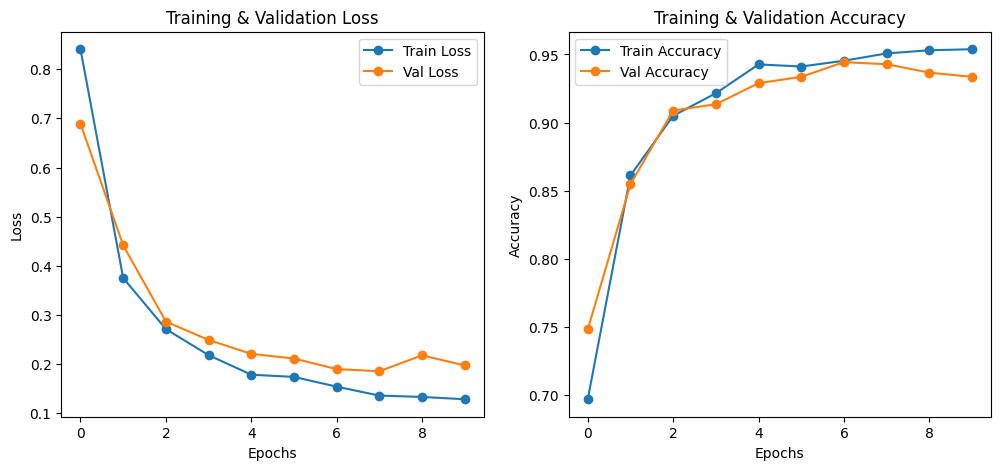

In [44]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(history):
    plt.figure(figsize=(12, 5))

    # 🔹 Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    # 🔹 Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training & Validation Accuracy')
    plt.legend()

    plt.show()

plot_loss_accuracy(history)


21/21 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step


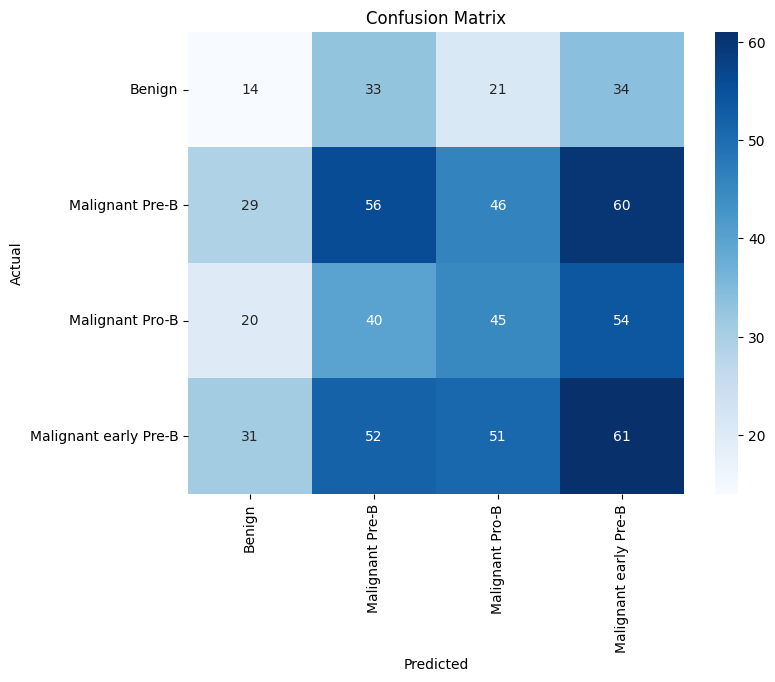

                       precision    recall  f1-score   support

               Benign       0.15      0.14      0.14       102
      Malignant Pre-B       0.31      0.29      0.30       191
      Malignant Pro-B       0.28      0.28      0.28       159
Malignant early Pre-B       0.29      0.31      0.30       195

             accuracy                           0.27       647
            macro avg       0.26      0.26      0.26       647
         weighted avg       0.27      0.27      0.27       647



In [45]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 🔹 Get True Labels & Predictions
true_labels = val_generator.classes
pred_probs = model.predict(val_generator)
pred_labels = np.argmax(pred_probs, axis=1)

# 🔹 Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 🔹 Classification Report (Precision, Recall, F1-score)
print(classification_report(true_labels, pred_labels, target_names=val_generator.class_indices.keys()))


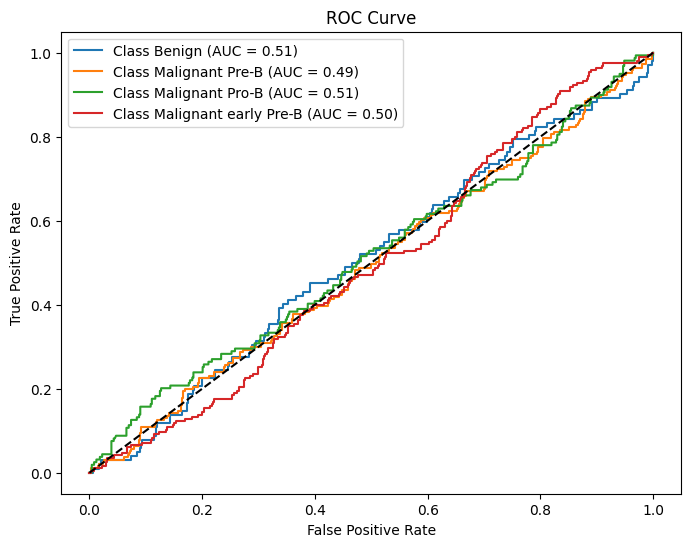

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 🔹 Convert True Labels to One-Hot Encoding
num_classes = len(val_generator.class_indices)
y_true = label_binarize(true_labels, classes=list(range(num_classes)))

# 🔹 Compute ROC for Each Class
plt.figure(figsize=(8, 6))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {list(val_generator.class_indices.keys())[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
